In [71]:
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr

In [72]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

📝 문제 1<br>
baseball 데이터셋은 야구팀의 홈런수와 타율에 관한 자료이다. 홈런수와 평균타율이 상관관계<br>
가 있는지 그 관련성을 분석하라

In [73]:
origin = load_data('baseball')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab11_/baseball.xlsx
[desc] 야구팀의 홈런수와 타율에 관한 자료 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (14, 2)
열 개수: 2
행 개수: 14

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   홈런수     14 non-null     int64  
 1   평균타율    14 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 356.0 bytes
None


,홈런수,평균타율
0,174,0.277
1,163,0.276
2,161,0.272
3,230,0.272
4,214,0.269


상관계수 

In [74]:
# 상관계수 계산 코드 예시
correlation = origin[['홈런수', '평균타율']].corr()
print(correlation)
print(f"홈런수와 평균타율간에는 강한 음의 상관관계가 나타난 것으로 알 수 있습니다.")

           홈런수      평균타율
홈런수   1.000000 -0.074695
평균타율 -0.074695  1.000000
홈런수와 평균타율간에는 강한 음의 상관관계가 나타난 것으로 알 수 있습니다.


평균타율에 따른 홈런수

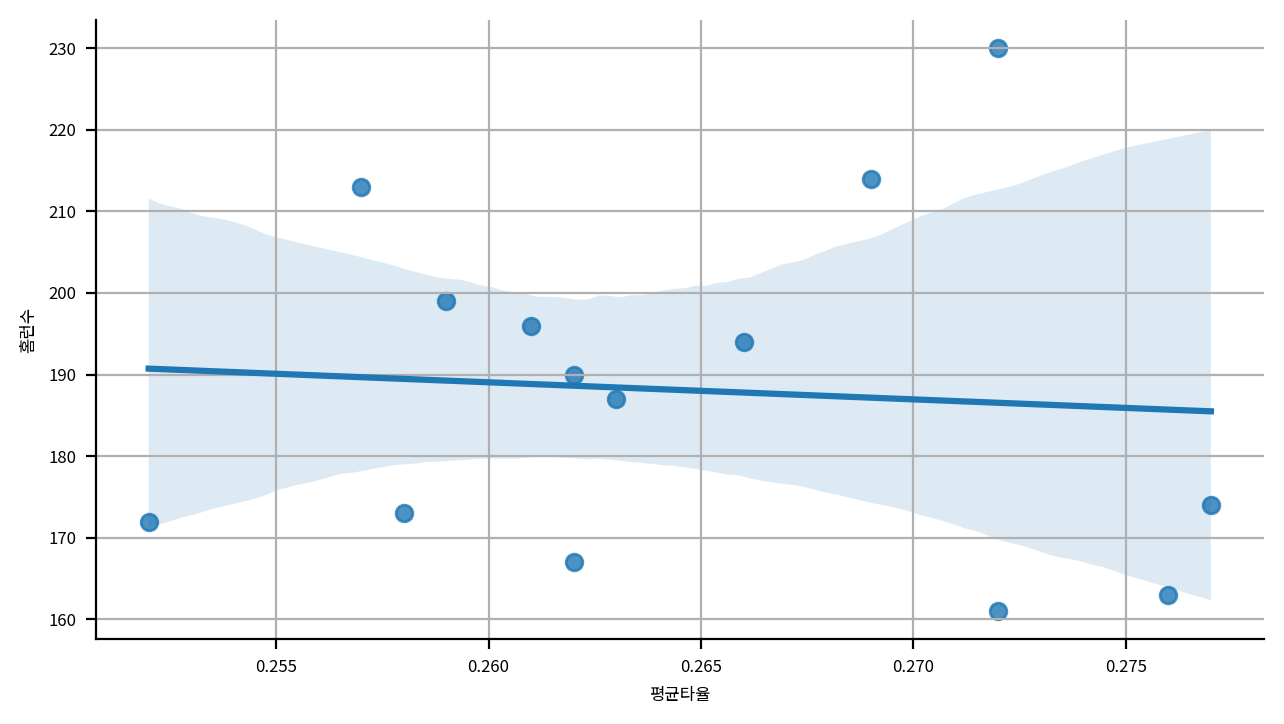

평균타율이 0.265 부근일때 , 오차 값이 가장 없다.
또한, 평균타율이 가장 컸을 때, 오히려 홈런수가 줄어들었다. 
그래프의 기울기가 아주 완만하지만, 음의 상관관계를 나타낸다는 것을 알 수 있다.


In [75]:
# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
# 2) LM Plot 그리기
g = sb.lmplot(data=origin, x="평균타율", y="홈런수")
g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])
plt.grid()
# 3) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료
print(f"평균타율이 0.265 부근일때 , 오차 값이 가장 없다.")
print(f"또한, 평균타율이 가장 컸을 때, 오히려 홈런수가 줄어들었다. ")
print(f"그래프의 기울기가 아주 완만하지만, 음의 상관관계를 나타낸다는 것을 알 수 있다.")

상관분석의 가정<br>


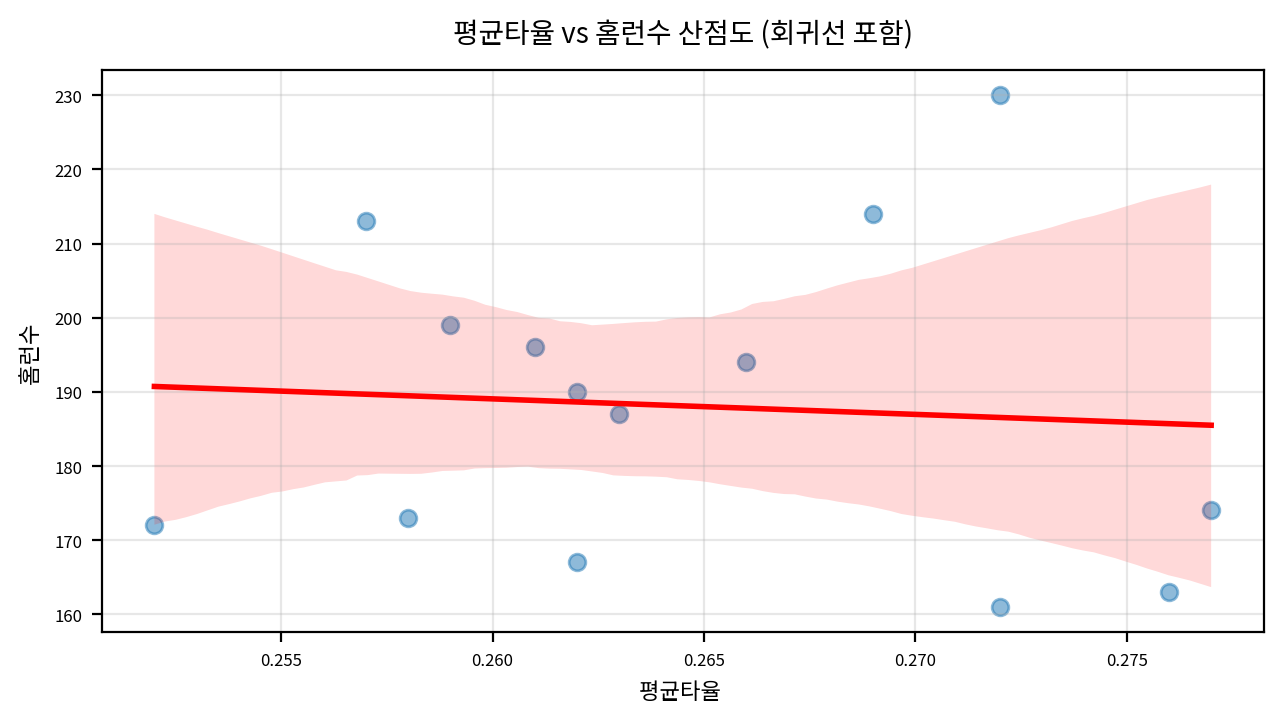

95%의 신뢰구간이 매우 넓게 나왔습니다.이를 통해, 편차가 너무 커서 추세선을 신뢰하기 어렵습니다.


In [76]:
# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1         # 그래프 행 수
cols = 1         # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) Scatter Plot 그리기 (회귀선 포함)
sb.regplot(
    data=origin,
    x='평균타율',
    y='홈런수',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'linewidth': 2}
)

# 3) 그래프 꾸미기
ax.set_title('평균타율 vs 홈런수 산점도 (회귀선 포함)', fontsize=10, pad=10)
ax.set_xlabel('평균타율 ', fontsize=8)
ax.set_ylabel('홈런수 ', fontsize=8)
ax.grid(True, alpha=0.3)  # 배경 격자 표시

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()          # 그래프 화면 출력
plt.close()         # 그래프 작업 종료
print(f"95%의 신뢰구간이 매우 넓게 나왔습니다.이를 통해, 편차가 너무 커서 추세선을 신뢰하기 어렵습니다.")

📝 문제 2<br>
product 데이터셋은 어떤 원료의 품질특성(x)과 이 원료를 사용하여 만든 제품의 특성(y)에 관한 조사를 한 결과 이다.<br>
이들 간 상관관계를 구하고 상관 유무 검정을 유의수준 5%에서 실시하라.

In [77]:
origin = load_data('product')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab11_/product.xlsx
[desc] 어떤 원료의 품질특성(x)과 이 원료를 사용하여 만든 제품의 특성(y)에 관한 조사결과 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (10, 2)
열 개수: 2
행 개수: 10

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       10 non-null     int64
 1   y       10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None


,x,y
0,36,29
1,40,32
2,34,29
3,44,40
4,33,31


In [78]:
chosen = "pearson" 
corr_matrix = origin[['x', 'y']].corr(method=chosen)
corr_matrix

from scipy.stats import pearsonr

x = origin['x']
y = origin['y']

r, p_value = pearsonr(x, y)
p_value = 0.0005990724739320283
print("Pearson r =", r)
print("p-value =", p_value)
print(f"r값이 약0.9안 것으로 보아, 강한 양의 상관관계를 띄고 잇다는 것을 알 수 있다. x가 증가할수록 y가 증가한다는 것을 알 수 있다.")
print(f"원료품질이 좋을수록 제품품질도 좋아진다는 해석을 할 수 있다.")

Pearson r = 0.8880516689960798
p-value = 0.0005990724739320283
r값이 약0.9안 것으로 보아, 강한 양의 상관관계를 띄고 잇다는 것을 알 수 있다. x가 증가할수록 y가 증가한다는 것을 알 수 있다.
원료품질이 좋을수록 제품품질도 좋아진다는 해석을 할 수 있다.


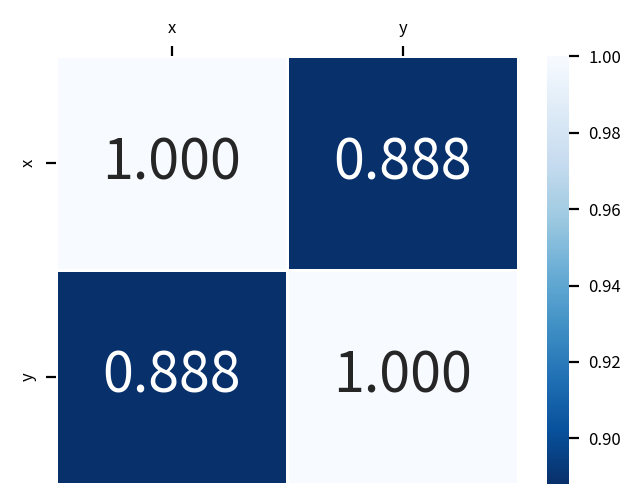

In [79]:
# 1) 그래프 초기화
width_px = 650 # 그래프 가로 크기
height_px = 500 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) heatmap 그리기
sb.heatmap(data=corr_matrix, annot=True, fmt="0.3f", linewidth=0.5,
cmap="Blues_r", annot_kws={"size": 20})
# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top() # x축의 변수 이름을 상단으로 이동
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

📝 문제 3<br>
study_time 은 학생들에 대한 공부 시간과 성적 데이터이다. 분석하라.

In [80]:
origin = load_data('study_time')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab11_/study_time.xlsx
[desc] 학생들에 대한 공부 시간과 성적 데이터 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (10, 2)
열 개수: 2
행 개수: 10

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   공부시간    10 non-null     int64
 1   성적      10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None


,공부시간,성적
0,2,65
1,4,85
2,3,75
3,5,90
4,6,95


In [81]:
from scipy.stats import pearsonr

# 분석할 변수 목록
cols = ['공부시간', '성적']

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        x = cols[i]
        y = cols[j]
        
        # NaN 제거
        data = origin[[x, y]].dropna()

        # 상관계수 및 p-value 계산
        corr, p_value = pearsonr(data[x], data[y])

        print(f"[{x}] - [{y}]")
        print(f"  상관계수: {corr:.4f}")
        print(f"  p-value : {p_value:.4f}")

        # 유의성 해석
        if p_value < 0.001:
            print("  → 매우 유의함 (p < 0.001)")
        elif p_value < 0.01:
            print("  → 유의함 (p < 0.01)")
        elif p_value < 0.05:
            print("  → 약하게 유의함 (p < 0.05)")
        else:
            print("  → 유의하지 않음")
        print("-" * 40)



[공부시간] - [성적]
  상관계수: 0.6842
  p-value : 0.0291
  → 약하게 유의함 (p < 0.05)
----------------------------------------


In [82]:
# 상관계수 계산 코드 예시
correlation = origin[['공부시간', '성적']].corr()
print(correlation)
print(f"양의 상관관계")

          공부시간        성적
공부시간  1.000000  0.684236
성적    0.684236  1.000000
양의 상관관계


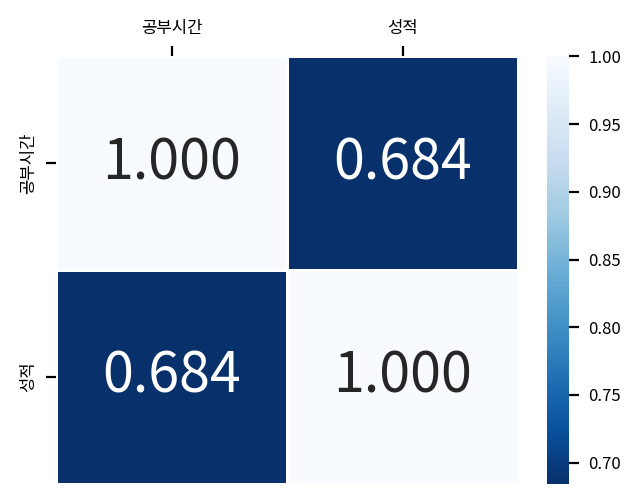

In [83]:
# 1) 그래프 초기화
width_px = 650 # 그래프 가로 크기
height_px = 500 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) heatmap 그리기
sb.heatmap(data=correlation, annot=True, fmt="0.3f", linewidth=0.5,
cmap="Blues_r", annot_kws={"size": 20})
# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top() # x축의 변수 이름을 상단으로 이동
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

penguins 데이터셋은 이터셋은 남극 Palmer 군도에서 채집된 펭귄들의 신체 특성을 포함하고<br>
있으며, 생태학적 패턴을 이해하는 데 널리 활용된다.<br>
이 데이터셋을 활용하여 펭귄의 주요 연속형 신체 측정값 간의 상관구조를 탐색하고, 부리 특성,<br>
지느러미 및 체중 등 생물학적 특성 간의 관계를 파악하시오.<br>

In [84]:
origin = load_data('penguins')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/kaggle/penguins.xlsx
[desc] 남극 팔머 군도의 펭귄 3종에 대해 신체 치수와 서식지 정보(출처: https://www.kaggle.com/datasets/larsen0966/penguins)

field              description
-----------------  -------------
species            팽귄 종
island             서식지
bill_length_mm     부리 길이
bill_depth_mm      부리 두께
flipper_length_mm  날개 길이
body_mass_g        몸무게
sex                성별


===== 데이터 크기 확인 =====
데이터셋 크기: (334, 7)
열 개수: 7
행 개수: 334

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   bill_length_mm     334 non-null    float64
 3   bill_depth_mm      334 non-null    float64
 4   flipper_length_mm  334 non-null    int64  
 5   body_mass_g        334 non-null    int64  
 6   sex                333 non-null    object 


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
2,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE
3,Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
4,Adelie,Torgersen,39.3,20.6,190,3650,MALE


In [85]:
species = origin['species'].unique()
species
island = origin['island'].unique()
island

print(f"species:{species}")
print(f"island:{island}")

species:['Adelie' 'Chinstrap' 'Gentoo']
island:['Torgersen' 'Biscoe' 'Dream']


species, island, bill_length_mm … 등 7개 컬럼 중에서 2개 컬럼을 고르는 모든 조합.

In [86]:
from itertools import combinations

cols = origin.columns.tolist()   # ['species', 'island', 'bill_length_mm', ... ]
col_combinations = list(combinations(cols, 2))

for c in col_combinations:
    print(c)


('species', 'island')
('species', 'bill_length_mm')
('species', 'bill_depth_mm')
('species', 'flipper_length_mm')
('species', 'body_mass_g')
('species', 'sex')
('island', 'bill_length_mm')
('island', 'bill_depth_mm')
('island', 'flipper_length_mm')
('island', 'body_mass_g')
('island', 'sex')
('bill_length_mm', 'bill_depth_mm')
('bill_length_mm', 'flipper_length_mm')
('bill_length_mm', 'body_mass_g')
('bill_length_mm', 'sex')
('bill_depth_mm', 'flipper_length_mm')
('bill_depth_mm', 'body_mass_g')
('bill_depth_mm', 'sex')
('flipper_length_mm', 'body_mass_g')
('flipper_length_mm', 'sex')
('body_mass_g', 'sex')


In [87]:
import pandas as pd
import numpy as np
from itertools import combinations

df = origin.copy()

# 수치형 / 범주형 자동 분리
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

def correlation_strength(r):
    if pd.isna(r):
        return "no relation"
    r = abs(r)
    if r >= 0.8:
        return "very strong"
    elif r >= 0.6:
        return "strong"
    elif r >= 0.4:
        return "medium"
    elif r >= 0.2:
        return "weak"
    else:
        return "very weak"

def has_outlier(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).any()

rows = []

for col1, col2 in combinations(df.columns, 2):
    s1, s2 = df[col1], df[col2]
    
    # 결측치 제거
    data = df[[col1, col2]].dropna()
    s1, s2 = data[col1], data[col2]
    
    # 타입 판정
    is_num1 = col1 in numeric_cols
    is_num2 = col2 in numeric_cols
    
    # ------------------------------
    # ① 두 컬럼 모두 수치형인 경우
    # ------------------------------
    if is_num1 and is_num2:
        corr = s1.corr(s2)
        strength = correlation_strength(corr)
        out1 = has_outlier(s1)
        out2 = has_outlier(s2)

        rows.append({
            "col1": col1,
            "col2": col2,
            "type": "numeric-numeric",
            "corr": corr,
            "strength": strength,
            "outlier_in_col1": out1,
            "outlier_in_col2": out2
        })
    
    # ------------------------------------------------
    # ② 하나는 범주형, 하나는 수치형 => 그룹별 평균 비교
    # ------------------------------------------------
    elif (is_num1 and not is_num2) or (not is_num1 and is_num2):
        
        if is_num1:  # numeric → s1
            numeric = s1
            category = s2
            ncol = col1
            ccol = col2
        else:
            numeric = s2
            category = s1
            ncol = col2
            ccol = col1

        # 범주별 평균
        group_mean = numeric.groupby(category).mean()
        diff = group_mean.max() - group_mean.min()

        rows.append({
            "col1": col1,
            "col2": col2,
            "type": "numeric-category",
            "category_groups": group_mean.to_dict(),
            "difference_max_min": diff
        })
    
    # --------------------------------------
    # ③ 둘 다 범주형인 경우 → 단순 교차 개수
    # --------------------------------------
    else:
        ct = pd.crosstab(s1, s2)
        rows.append({
            "col1": col1,
            "col2": col2,
            "type": "category-category",
            "cross_table": ct
        })

summary = pd.DataFrame(rows)
summary


,col1,col2,type,cross_table,category_groups,difference_max_min,corr,strength,outlier_in_col1,outlier_in_col2
0,species,island,category-category,island Biscoe Dream Torgersen species ...,NaN,NaN,NaN,NaN,NaN,NaN
1,species,bill_length_mm,numeric-category,NaN,"{'Adelie': 38.81496598639456, 'Chinstrap': 48....",10.018858,NaN,NaN,NaN,NaN
2,species,bill_depth_mm,numeric-category,NaN,"{'Adelie': 18.351020408163265, 'Chinstrap': 18...",3.423950,NaN,NaN,NaN,NaN
3,species,flipper_length_mm,numeric-category,NaN,"{'Adelie': 190.02721088435374, 'Chinstrap': 19...",27.208083,NaN,NaN,NaN,NaN
4,species,body_mass_g,numeric-category,NaN,"{'Adelie': 3701.190476190476, 'Chinstrap': 373...",1391.246499,NaN,NaN,NaN,NaN
5,species,sex,category-category,sex FEMALE MALE species ...,NaN,NaN,NaN,NaN,NaN,NaN
6,island,bill_length_mm,numeric-category,NaN,"{'Biscoe': 45.24846625766871, 'Dream': 44.1677...",6.210168,NaN,NaN,NaN,NaN
7,island,bill_depth_mm,numeric-category,NaN,"{'Biscoe': 15.907361963190185, 'Dream': 18.344...",2.543702,NaN,NaN,NaN,NaN
8,island,flipper_length_mm,numeric-category,NaN,"{'Biscoe': 209.55828220858896, 'Dream': 193.07...",18.026367,NaN,NaN,NaN,NaN
9,island,body_mass_g,numeric-category,NaN,"{'Biscoe': 4719.171779141105, 'Dream': 3712.90...",1010.661141,NaN,NaN,NaN,NaN


In [88]:
from itertools import combinations

num_cols = num_df.columns
results = []

for c1, c2 in combinations(num_cols, 2):
    r = num_df[c1].corr(num_df[c2])
    results.append([c1, c2, r])

pd.DataFrame(results, columns=["col1", "col2", "correlation"])


,col1,col2,correlation
0,bill_length_mm,bill_depth_mm,-0.231009
1,bill_length_mm,flipper_length_mm,0.654883
2,bill_length_mm,body_mass_g,0.591575
3,bill_depth_mm,flipper_length_mm,-0.579130
4,bill_depth_mm,body_mass_g,-0.473848
5,flipper_length_mm,body_mass_g,0.873885


숫자형 변수 자동 선택 → 상관계수 계산 → 강도 분류 함수

In [93]:
import pandas as pd
import numpy as np
from itertools import combinations

# 숫자형 변수만 선택
num_df = origin.select_dtypes(include=[np.number])

# 상관 강도 문구 변환 함수
def strength_label(r):
    if pd.isna(r):
        return "no relation"
    r_abs = abs(r)
    if r_abs >= 0.8:
        return "매우 강한 상관"
    elif r_abs >= 0.6:
        return "강한 상관"
    elif r_abs >= 0.4:
        return "중간 정도 상관"
    elif r_abs >= 0.2:
        return "약한 상관"
    else:
        return "거의 없음"



모든 숫자형 변수 조합별 상관계수/강도 계산

In [97]:
results = []

for col1, col2 in combinations(num_df.columns, 2):
    r = num_df[col1].corr(num_df[col2])
    label = strength_label(r)
    direction = "양의" if r > 0 else "음의" if r < 0 else "0"
    
    results.append({
        "변수1": col1,
        "변수2": col2,
        "상관계수": r,
        "강도": label,
        "방향": direction
    })

corr_df = pd.DataFrame(results)
corr_df


,변수1,변수2,상관계수,강도,방향
0,bill_length_mm,bill_depth_mm,-0.231009,약한 상관,음의
1,bill_length_mm,flipper_length_mm,0.654883,강한 상관,양의
2,bill_length_mm,body_mass_g,0.591575,중간 정도 상관,양의
3,bill_depth_mm,flipper_length_mm,-0.579130,중간 정도 상관,음의
4,bill_depth_mm,body_mass_g,-0.473848,중간 정도 상관,음의
5,flipper_length_mm,body_mass_g,0.873885,매우 강한 상관,양의


자연어 요약 리포트 자동 생성

In [99]:
report = []

for _, row in corr_df.iterrows():
    col1 = row["변수1"]
    col2 = row["변수2"]
    label = row["강도"]
    direction = row["방향"]
    r = row["상관계수"]

    if direction == "양의":
        text = f"{label}: {col1}와 {col2}는 양의 상관(r={r:.3f})을 보입니다."
    elif direction == "음의":
        text = f"{label}: {col1}와 {col2}는 음의 상관(r={r:.3f})을 보입니다."
    else:
        text = f"{col1}와 {col2}는 상관이 거의 없습니다."

    report.append(text)

for line in report:
    print(line)


약한 상관: bill_length_mm와 bill_depth_mm는 음의 상관(r=-0.231)을 보입니다.
강한 상관: bill_length_mm와 flipper_length_mm는 양의 상관(r=0.655)을 보입니다.
중간 정도 상관: bill_length_mm와 body_mass_g는 양의 상관(r=0.592)을 보입니다.
중간 정도 상관: bill_depth_mm와 flipper_length_mm는 음의 상관(r=-0.579)을 보입니다.
중간 정도 상관: bill_depth_mm와 body_mass_g는 음의 상관(r=-0.474)을 보입니다.
매우 강한 상관: flipper_length_mm와 body_mass_g는 양의 상관(r=0.874)을 보입니다.


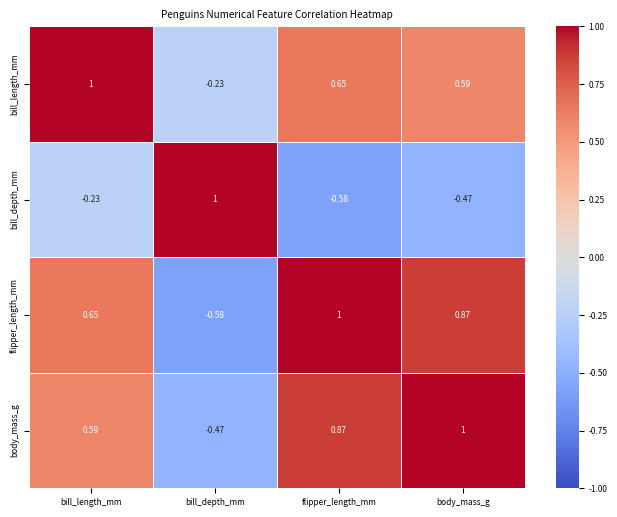

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 숫자형 변수만 선택
num_df = origin.select_dtypes(include=[np.number])

# 상관계수 계산
corr = num_df.corr(method='pearson')

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Penguins Numerical Feature Correlation Heatmap")
plt.show()


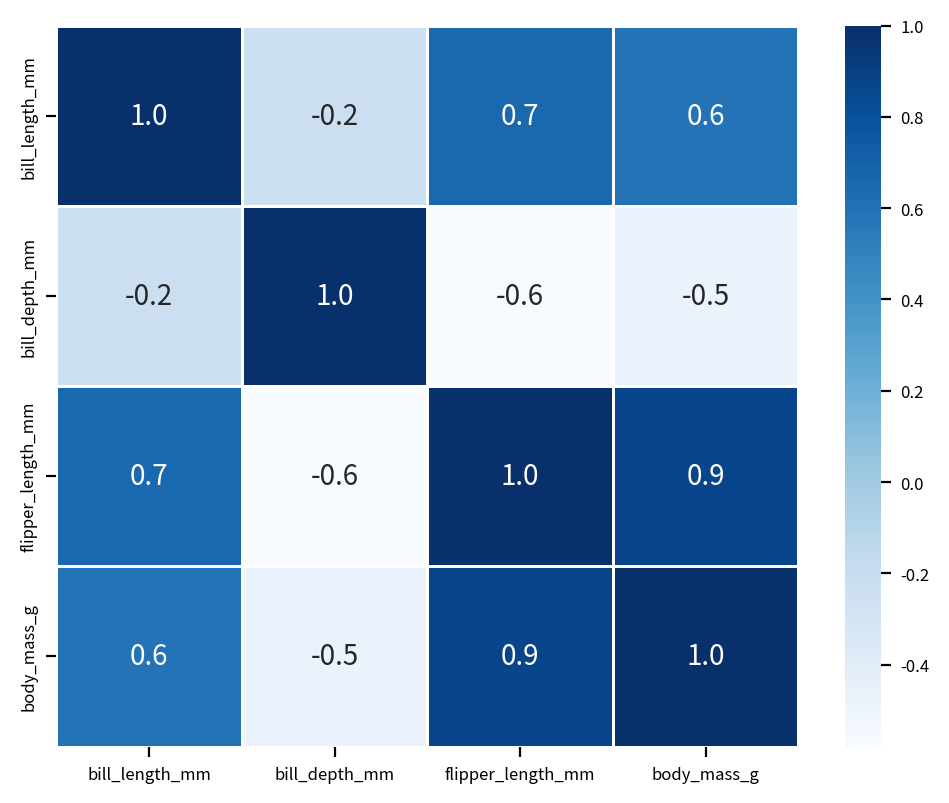

In [105]:
# 1) 그래프 초기화
width_px = 1000 # 그래프 가로 크기
height_px = 800 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) heatmap 그리기
sb.heatmap(data=corr, annot=True, fmt="0.1f", linewidth=0.5,
cmap="Blues", annot_kws={"size": 10})
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

📘 #05. 인사이트<br>
📝 1. 부리 길이(bill_length_mm) 관련 변수들<br>
bill_length_mm–bill_depth_mm의 경우 비선형성이 확인되어 스피어만 상관계수를 적용하<br>
였고, 약한 수준의 음의 단조 관계(ρ = −0.2162, p < 0.001)가 통계적으로 유의하였다.<br>
bill_length_mm–flipper_length_mm에서도 비선형성이 관찰되어 스피어만 상관계수를 사<br>
용하였으며, 중간 수준의 양의 단조 관계(ρ = 0.6715, p < 0.001)가 나타났다.<br>
bill_length_mm–body_mass_g 역시 비선형성이 있어 스피어만 상관계수를 적용하였고,<br>
중간 수준의 양의 단조 관계(ρ = 0.5792, p < 0.001)가 확인되었다.<br>
📝 2. 부리 깊이(bill_depth_mm) 관련 변수들<br>
bill_depth_mm–flipper_length_mm에서는 비선형성이 확인되어 스피어만 상관계수를 사<br>
용하였고, 중간 수준의 음의 단조 관계(ρ = −0.5183, p < 0.001)가 나타났다.<br>
bill_depth_mm–body_mass_g 역시 스피어만 상관계수를 적용하였으며, 중간 수준의 음의<br>
단조 관계(ρ = −0.4307, p < 0.001)가 통계적으로 유의하였다.<br>
📝 3. 지느러미 길이(flipper_length_mm) 및 체중<br>
(body_mass_g) 관련 상관<br>
flipper_length_mm–body_mass_g는 비선형성이 존재하여 스피어만 상관계수를 사용하였<br>
고, 강한 수준의 양의 단조 관계(ρ = 0.8416, p < 0.001)가 확인되었다.<br>